# Unsupervised Anomaly Detection

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.stats import mannwhitneyu
pd.set_option('display.max_columns', 60)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
ART_DIR = Path('../artifacts')

In [2]:
df = pd.read_csv(ART_DIR / 'preprocessed_cert_features.csv')
df.shape

(1000, 24)

In [3]:
df.head()

,user,total_logons,avg_logon_hour,std_logon_hour,weekend_logons,after_hours_logons,unique_pcs_logon,total_device_activities,device_connects,device_disconnects,unique_pcs_device,avg_device_hour,after_hours_device,total_file_activities,unique_files,unique_pcs_file,avg_file_hour,after_hours_files,employee_name,O,C,E,A,N
0,YVD0093,692,10.500000,3.502532,0,0,1,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,Yvette Vivien Donovan,38,19,29,15,36
1,TAC0118,1214,11.327018,3.633813,0,0,2,677.0,342.0,335.0,1.0,11.472674,0.0,655.0,655.0,1.0,11.735878,0.0,Troy Alvin Craig,34,40,24,15,34
2,EJM0952,1198,12.999165,3.698879,24,0,2,275.0,138.0,137.0,1.0,12.952727,0.0,302.0,302.0,1.0,12.529801,0.0,Eden Jocelyn Mcclain,20,37,48,35,34
3,AEW0655,692,10.562139,4.043599,0,155,1,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,Alexa Emma Wood,25,20,18,40,38
4,CMG0936,968,11.063017,3.879407,0,158,2,265.0,134.0,131.0,1.0,11.177358,1.0,288.0,288.0,1.0,11.225694,0.0,Celeste Maris Griffith,36,13,18,50,29


In [4]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
len(numerical_cols)

22

## Prepare and scale

Modelling on the numeric behavioural + psychometric columns only.

In [5]:
X = df[numerical_cols].replace([np.inf, -np.inf], np.nan).fillna(df[numerical_cols].median())
X.shape

(1000, 22)

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled.shape

(1000, 22)

## Isolation Forest

Isolation Forest isolates points with random splits; anomalies need fewer splits and get more negative scores. Contamination only sets the cut on a fixed score ranking.

In [7]:
iso_sweep = []
for c in [0.1, 0.05, 0.01]:
    m = IsolationForest(contamination=c, n_estimators=100, random_state=42, bootstrap=False)
    pred = m.fit_predict(X_scaled)
    iso_sweep.append({'contamination': c, 'n_anomalies': int((pred == -1).sum())})
pd.DataFrame(iso_sweep)

,contamination,n_anomalies
0,0.10,100
1,0.05,50
2,0.01,10


The count scales exactly with contamination (100 / 50 / 10 users) because contamination is just a quantile cut on a fixed score ordering — it does not change which users rank as most anomalous, only how many we accept. We adopt **5%** as a middle ground: broad enough to capture a meaningful risk pool, tight enough to stay investigable.

In [8]:
iso = IsolationForest(contamination=0.05, n_estimators=100, random_state=42, bootstrap=False)
df['iso_pred'] = iso.fit_predict(X_scaled)
df['iso_score'] = iso.score_samples(X_scaled)
df['iso_anomaly'] = (df['iso_pred'] == -1).astype(int)
df['iso_anomaly'].sum()

np.int64(50)

## Local Outlier Factor

LOF compares each user's local density to that of its neighbours, so it can flag points that are odd relative to their local cluster even if not globally extreme. The neighbourhood size is its key knob; we sweep neighbours and contamination together.

In [9]:
lof_sweep = []
for n in [10, 20, 30, 50]:
    for c in [0.1, 0.05, 0.01]:
        m = LocalOutlierFactor(n_neighbors=n, contamination=c)
        pred = m.fit_predict(X_scaled)
        lof_sweep.append({'n_neighbors': n, 'contamination': c,
                          'n_anomalies': int((pred == -1).sum())})
lof_sweep_df = pd.DataFrame(lof_sweep)
lof_sweep_df


,n_neighbors,contamination,n_anomalies
0,10,0.10,100
1,10,0.05,50
2,10,0.01,10
3,20,0.10,100
4,20,0.05,50
5,20,0.01,10
6,30,0.10,100
7,30,0.05,50
8,30,0.01,10
9,50,0.10,100


As with Isolation Forest, the flagged count tracks contamination directly. The neighbourhood size mainly reshuffles which users sit at the boundary rather than how many are flagged. We fix n_neighbors=20 (a common default that balances local detail against noise) at 5% contamination so the two detectors flag equal-sized sets and are directly comparable.

In [10]:
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
df['lof_pred'] = lof.fit_predict(X_scaled)
df['lof_score'] = lof.negative_outlier_factor_
df['lof_anomaly'] = (df['lof_pred'] == -1).astype(int)
df['lof_anomaly'].sum()

np.int64(50)

## Consensus labels

With two equal-sized flagged sets we form two label policies. Strict = flagged by both detectors (high precision, low recall). Loose = flagged by either (high recall, more false positives).

In [11]:
df['consensus_strict'] = ((df['iso_anomaly'] == 1) & (df['lof_anomaly'] == 1)).astype(int)
df['consensus_loose'] = ((df['iso_anomaly'] == 1) | (df['lof_anomaly'] == 1)).astype(int)
df[['iso_anomaly', 'lof_anomaly', 'consensus_strict', 'consensus_loose']].sum()

iso_anomaly         50
lof_anomaly         50
consensus_strict    10
consensus_loose     90
dtype: int64

In [12]:
pd.crosstab(df['iso_anomaly'], df['lof_anomaly'],
            rownames=['iso'], colnames=['lof'], margins=True)

lof,0,1,All
iso,,,
0,910,40,950
1,40,10,50
All,950,50,1000


Each detector flags 50 users; only 10 are common to both (strict consensus), and the union is 90 (loose). The two methods overlap on just 20% of their flags — they are capturing largely different anomalies. That is the expected consequence of their different biases: Isolation Forest favours globally extreme users, LOF favours users odd within their local neighbourhood. The 10-user strict set is our high-confidence core.

In [13]:
strict = df[df['consensus_strict'] == 1]
strict[['user', 'iso_score', 'lof_score', 'total_logons',
        'after_hours_logons', 'weekend_logons']].sort_values('total_logons', ascending=False)


,user,iso_score,lof_score,total_logons,after_hours_logons,weekend_logons
938,PHJ0041,-0.760780,-4.740584,3995,1818,700
380,WCR0044,-0.775384,-3.027868,3785,1857,591
252,SAM0359,-0.757942,-4.923739,3474,1814,610
229,NPA0366,-0.722752,-4.689270,3241,1541,0
822,BJW0369,-0.750884,-3.647039,3177,1647,0
42,PWS0219,-0.725625,-4.867406,3150,1634,0
937,DGS0220,-0.741008,-4.915485,2872,1661,0
839,FLC0370,-0.758853,-3.246941,2794,1561,4
226,TGR0912,-0.641131,-1.860898,1395,212,308
676,SPW0142,-0.670290,-1.446807,1370,478,341


The strict-consensus users are dominated by extreme logon volume and very high after-hours / weekend activity — the textbook insider-threat timing signature. Both a global and a local detector independently agreeing on these users is strong evidence they are genuine behavioural outliers.

## Score distributions

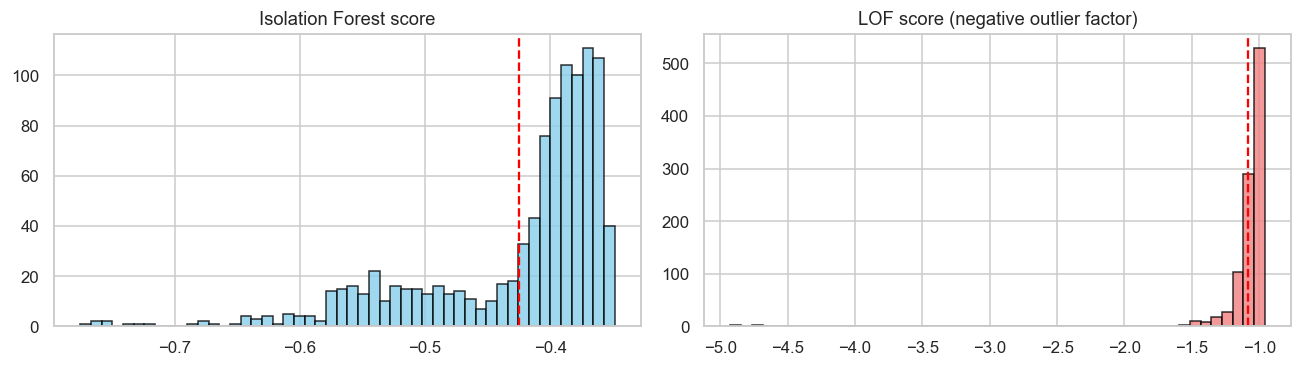

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].hist(df['iso_score'], bins=50, color='skyblue', edgecolor='black', alpha=0.8)
axes[0].axvline(df['iso_score'].mean(), color='red', ls='--')
axes[0].set_title('Isolation Forest score')
axes[1].hist(df['lof_score'], bins=50, color='lightcoral', edgecolor='black', alpha=0.8)
axes[1].axvline(df['lof_score'].mean(), color='red', ls='--')
axes[1].set_title('LOF score (negative outlier factor)')
plt.tight_layout()
plt.show()


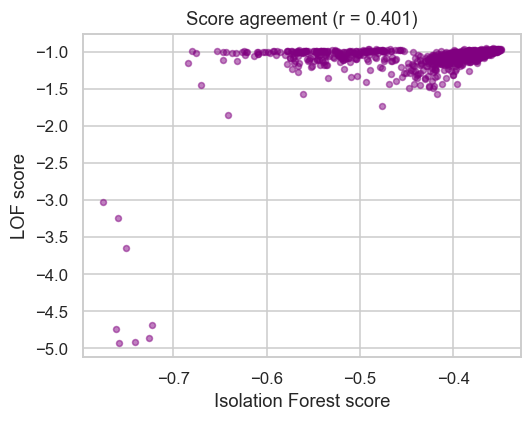

In [15]:
r = df['iso_score'].corr(df['lof_score'])
plt.figure(figsize=(5, 4))
plt.scatter(df['iso_score'], df['lof_score'], s=15, alpha=0.5, c='purple')
plt.xlabel('Isolation Forest score'); plt.ylabel('LOF score')
plt.title(f'Score agreement (r = {r:.3f})')
plt.tight_layout()
plt.show()


Isolation Forest scores are tight and unimodal with a short anomalous tail; LOF scores have a long heavy tail (a few users with extreme local-density ratios). The weak score correlation echoes the 20% label overlap — the detectors rank users differently, which is why combining them is informative rather than redundant.

## PCA projection

To see the flagged users in two dimensions we project the standardised features onto their first two principal components and overlay each label policy.

In [16]:
pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(X_scaled)
df['pc1'], df['pc2'] = pcs[:, 0], pcs[:, 1]
pca.explained_variance_ratio_.round(3)


array([0.309, 0.189])

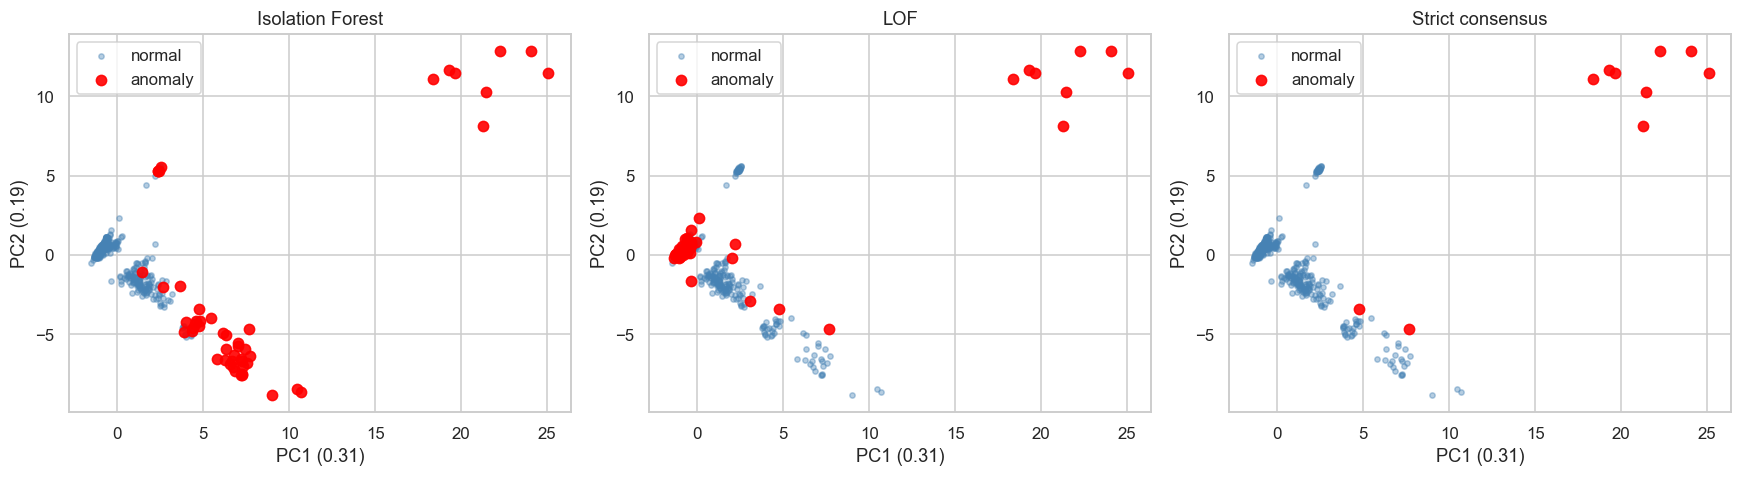

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (col, title) in zip(axes, [('iso_anomaly', 'Isolation Forest'),
                                   ('lof_anomaly', 'LOF'),
                                   ('consensus_strict', 'Strict consensus')]):
    normal = df[df[col] == 0]
    anom = df[df[col] == 1]
    ax.scatter(normal['pc1'], normal['pc2'], s=12, alpha=0.4, c='steelblue', label='normal')
    ax.scatter(anom['pc1'], anom['pc2'], s=45, alpha=0.9, c='red', label='anomaly')
    ax.set_title(title)
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2f})')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2f})')
    ax.legend()
plt.tight_layout()
plt.show()


The first two components explain only ~50% of variance, so 2-D is a partial view. Still, Isolation Forest's flags sit clearly on the outer edge of the cloud (globally extreme), while several LOF flags fall nearer the centre (locally odd but not globally extreme). The strict-consensus points are the extreme-edge users both methods agree on.

In [18]:
loadings = pd.DataFrame(pca.components_[:2].T, index=numerical_cols, columns=['PC1', 'PC2'])
loadings.reindex(loadings['PC1'].abs().sort_values(ascending=False).index).head(8).round(3)


,PC1,PC2
after_hours_device,0.298,0.221
after_hours_files,0.292,0.233
unique_pcs_file,0.286,0.240
unique_pcs_device,0.285,0.241
device_disconnects,0.277,-0.283
total_device_activities,0.277,-0.283
device_connects,0.277,-0.283
total_file_activities,0.276,-0.216


PC1 is loaded mainly by after-hours and unique-PC device/file features — it is essentially an 'after-hours, multi-machine intensity' axis. This matches the domain expectation that after-hours and device-spread behaviour is the dominant axis of variation among users.

## Evaluation

Without ground truth we evaluate via internal measures: how well the labels separate in feature space (silhouette), how far apart the score distributions are, how much the two detectors agree (ARI, Jaccard), and whether the score gap is statistically real (Mann-Whitney).

In [19]:
percentiles = pd.DataFrame({
    'iso_score': np.percentile(df['iso_score'], [5, 25, 50, 75, 95]),
    'lof_score': np.percentile(df['lof_score'], [5, 25, 50, 75, 95]),
}, index=['p5', 'p25', 'p50', 'p75', 'p95']).round(3)
percentiles


,iso_score,lof_score
p5,-0.572,-1.268
p25,-0.451,-1.082
p50,-0.395,-1.032
p75,-0.373,-1.001
p95,-0.358,-0.979


In [20]:
sil = {
    'iso': silhouette_score(X_scaled, df['iso_anomaly']),
    'lof': silhouette_score(X_scaled, df['lof_anomaly']),
    'strict': silhouette_score(X_scaled, df['consensus_strict']),
}
{k: round(v, 4) for k, v in sil.items()}


{'iso': 0.6124, 'lof': 0.4042, 'strict': 0.7715}

Strict consensus gives the highest silhouette — the 10 agreed users are the most cleanly separated group in feature space, confirming they are the tightest, most defensible anomaly cluster. Isolation Forest separates better than LOF, consistent with its flags being globally extreme (easier to separate) versus LOF's locally-odd flags.

In [21]:
def sep(score_col, label_col):
    a = df.loc[df[label_col] == 1, score_col]
    n = df.loc[df[label_col] == 0, score_col]
    return abs(a.mean() - n.mean())
{'iso_separation': round(sep('iso_score', 'iso_anomaly'), 4),
 'lof_separation': round(sep('lof_score', 'lof_anomaly'), 4)}


{'iso_separation': np.float64(0.2199), 'lof_separation': np.float64(0.8103)}

In [22]:
ari = adjusted_rand_score(df['iso_anomaly'], df['lof_anomaly'])
inter = ((df['iso_anomaly'] == 1) & (df['lof_anomaly'] == 1)).sum()
union = ((df['iso_anomaly'] == 1) | (df['lof_anomaly'] == 1)).sum()
{'adjusted_rand_index': round(ari, 4), 'jaccard': round(inter / union, 4)}


{'adjusted_rand_index': 0.1438, 'jaccard': np.float64(0.1111)}

ARI ≈ 0.14 and Jaccard ≈ 0.11 both confirm weak agreement between the detectors — they are complementary, not interchangeable. This is the quantitative justification for keeping both and forming consensus labels rather than trusting a single method.

In [23]:
iso_u, iso_p = mannwhitneyu(df.loc[df.iso_anomaly == 0, 'iso_score'],
                             df.loc[df.iso_anomaly == 1, 'iso_score'])
lof_u, lof_p = mannwhitneyu(df.loc[df.lof_anomaly == 0, 'lof_score'],
                            df.loc[df.lof_anomaly == 1, 'lof_score'])
{'iso_pvalue': iso_p, 'lof_pvalue': lof_p}


{'iso_pvalue': np.float64(8.14689401954481e-33),
 'lof_pvalue': np.float64(8.14689401954481e-33)}

Both p-values are vanishingly small — the anomaly and normal score distributions are very significantly different for each detector. The flagged users are not arbitrary cuts; they sit in a genuinely distinct region of each detector's score space.

## Stability

Labels are only useful downstream if they are reproducible. We re-fit Isolation Forest across several random seeds and check the flagged count is stable.

In [24]:
seeds = [42, 123, 456, 789, 101112]
iso_counts = []
for s in seeds:
    m = IsolationForest(contamination=0.05, n_estimators=100, random_state=s, bootstrap=False)
    iso_counts.append(int((m.fit_predict(X_scaled) == -1).sum()))
iso_counts


[50, 50, 50, 50, 50]

In [25]:
cv = np.std(iso_counts) / np.mean(iso_counts) if np.mean(iso_counts) else 0
{'mean': float(np.mean(iso_counts)), 'std': float(np.std(iso_counts)), 'cv': round(cv, 4)}

{'mean': 50.0, 'std': 0.0, 'cv': np.float64(0.0)}

The flagged count is identical across seeds (CV = 0). Contamination pins the count by construction, and with 100 trees the score ranking is stable enough that the *same* users are flagged each time. The labels are reproducible and safe to carry into supervised training.

## Export labelled dataset

In [26]:
export_cols = (numerical_cols + ['user',
               'iso_score', 'iso_anomaly', 'lof_score', 'lof_anomaly',
               'consensus_strict', 'consensus_loose'])
out = df[export_cols].copy()
out.shape


(1000, 29)

In [27]:
out.to_csv(ART_DIR / 'cert_dataset_with_anomaly_labels.csv', index=False)

In [28]:
out.to_parquet(ART_DIR / 'cert_dataset_with_anomaly_labels.parquet', index=False)

In [29]:
out[['consensus_strict', 'consensus_loose']].sum().to_dict()


{'consensus_strict': 10, 'consensus_loose': 90}